# Практика 3 — MCP, Skills 

---
## 0. Подготовка

In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys
import json
import asyncio
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "pyproject.toml").exists():
            return p
    return start


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# nest_asyncio нужен для работы asyncio внутри Jupyter
import nest_asyncio

nest_asyncio.apply()

from src.config import settings
from openai import OpenAI

In [2]:
client = OpenAI(
    base_url="https://api.polza.ai/api/v1",
    api_key=settings.polza_ai_api_key,
)

# ============================================================
# Основной клиент и модель
# ============================================================

MODEL = "openai/gpt-4o"

---
## 1. MCP — Model Context Protocol: зачем и как


```
Агент A ──┐                      ┌── MCP Server 1 (обсерватория)
Агент B ──┼── MCP (единый) ──────┼── MCP Server 2 (база данных)
Агент C ──┘                      └── MCP Server 3 (файлы)
```

### Архитектура MCP

| Компонент | Роль |
|-----------|------|
| **MCP Host** | Приложение, которому нужны данные/инструменты (IDE, чатбот, агент) |
| **MCP Client** | Протокольный клиент внутри хоста — устанавливает соединение |
| **MCP Server** | Легковесный сервис, предоставляющий возможности через стандартный протокол |

### Три типа возможностей MCP-сервера

| Тип | Кто контролирует | Описание |
|-----|-----------------|----------|
| **Tools** | Модель (LLM) | Функции, которые модель вызывает сама (≈ function calling) |
| **Resources** | Приложение | Данные, доступные для чтения (≈ GET-запрос, файл) |
| **Prompts** | Пользователь | Готовые шаблоны для типовых задач |

> **Ключевая идея**: MCP стандартизирует **discovery** (какие инструменты есть?) и **invocation** (как их вызывать?) — модель получает формальное описание возможностей.

---
## 2. MCP-сервер: космическая обсерватория

Мы будем работать с MCP-сервером **«Космическая обсерватория»** (`space_mcp_server.py`).

### Что внутри сервера

Сервер содержит данные о:
- 🪐 **Планеты** Солнечной системы (9 объектов, включая Плутон)
- ⭐ **Звёзды** (8 известных звёзд: Сириус, Бетельгейзе, Вега...)
- 🌌 **Созвездия** (5 созвездий с мифологией и объектами)
- 🛰️ **Космические миссии** (Вояджер-1, Джеймс Уэбб, Персеверанс...)

### Инструменты (Tools)

| Инструмент | Описание |
|-----------|----------|
| `get_planet(name)` | Подробная информация о планете |
| `list_planets(planet_type)` | Список планет с фильтрацией |
| `get_star(name)` | Информация о звезде |
| `list_stars(constellation)` | Список звёзд |
| `get_constellation(name)` | Информация о созвездии |
| `get_mission(name)` | Информация о миссии |
| `search_objects(query)` | Полнотекстовый поиск |
| `calculate_light_travel(distance_ly)` | Время полёта света |
| `convert_units(value, from, to)` | Конвертация единиц |

### Ресурсы (Resources)

| URI | Описание |
|-----|----------|
| `observatory://catalog` | Полный каталог всех объектов |

### Как устроен MCP-сервер на Python (FastMCP)

```python
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("space-observatory")

@mcp.tool()
async def get_planet(name: str) -> str:
    """Получить информацию о планете."""
    ...

@mcp.resource("observatory://catalog")
async def get_catalog() -> str:
    """Полный каталог обсерватории."""
    ...

if __name__ == "__main__":
    mcp.run(transport="stdio")
```

> **Обратите внимание**: `FastMCP` автоматически генерирует JSON-схемы из **type hints** и **docstrings**. Не нужно вручную описывать `parameters` — это делает протокол.

---
## 3. MCP-клиент: подключение, discovery, вызов инструментов

### Как работает MCP-клиент

1. **Подключение** — клиент запускает MCP-сервер как subprocess (транспорт `stdio`)
2. **Инициализация** — handshake, обмен версиями протокола
3. **Discovery** — клиент запрашивает список доступных **tools**, **resources**, **prompts**
4. **Вызов** — стандартизированный вызов любого инструмента по имени + аргументам

```
MCP Client                          MCP Server
    │                                    │
    │──── initialize ───────────────────►│
    │◄─── server capabilities ───────────│
    │                                    │
    │──── tools/list ───────────────────►│  ← Discovery
    │◄─── [{name, description, schema}]──│
    │                                    │
    │──── tools/call(name, args) ───────►│  ← Invocation
    │◄─── result ────────────────────────│
```
Го


In [4]:
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

# ============================================================
# Путь к нашему MCP-серверу
# ============================================================
SERVER_PATH = str(PROJECT_ROOT / "lectures" / "lecture_3" / "space_mcp_server.py")

# Параметры подключения — stdio транспорт
server_params = StdioServerParameters(
    command=sys.executable,
    args=[SERVER_PATH],
    env=None,
)

print(f"Команда: {sys.executable}")
print(f"Аргументы: {SERVER_PATH}")
print("\nПараметры сервера готовы ✓")

Команда: c:\Users\isami\OneDrive\Рабочий стол\Projects\Personal\ВШЭ\HSE-Agent-Systems_2026\.venv\Scripts\python.exe
Аргументы: c:\Users\isami\OneDrive\Рабочий стол\Projects\Personal\ВШЭ\HSE-Agent-Systems_2026\lectures\lecture_3\space_mcp_server.py

Параметры сервера готовы ✓


### 3.1 Discovery — узнаём, что умеет сервер

Первое, что делает MCP-клиент — **discovery**: запрашивает список всех доступных tools, resources и prompts.

Это ключевое отличие от ручного описания инструментов:
- **Раньше**: мы сами писали JSON-схемы (`TOOLS_SCHEMA = [...]`)
- **Теперь**: сервер **сам** сообщает, что он умеет. Клиент получает описания автоматически.

In [5]:
# ============================================================
# Discovery: подключаемся к серверу и узнаём его возможности
# ============================================================

import os


async def discover_server():
    """Подключиться к MCP-серверу и получить список возможностей."""
    # В Jupyter на Windows у sys.stderr нет fileno(), а MCP ожидает файловый stream.
    with open(os.devnull, "w", encoding="utf-8") as errlog:
        async with stdio_client(server_params, errlog=errlog) as (read_stream, write_stream):
            async with ClientSession(read_stream, write_stream) as session:
                # 1. Инициализация — handshake
                await session.initialize()
                print("✅ Подключение установлено!\n")

                # 2. Discovery: Tools
                tools_response = await session.list_tools()
                print(f"🔧 Инструменты ({len(tools_response.tools)}):")
                print("-" * 50)
                for tool in tools_response.tools:
                    description = tool.description or ""
                    print(f"  • {tool.name}")
                    print(f"    {description[:80]}...")
                    print()

                # 3. Discovery: Resources
                resources_response = await session.list_resources()
                print(f"📦 Ресурсы ({len(resources_response.resources)}):")
                print("-" * 50)
                for resource in resources_response.resources:
                    print(f"  • {resource.uri}")
                    print(f"    {resource.description}")
                    print()

                return tools_response.tools, resources_response.resources


tools, resources = asyncio.get_event_loop().run_until_complete(discover_server())

✅ Подключение установлено!

🔧 Инструменты (9):
--------------------------------------------------
  • get_planet
    Получить подробную информацию о планете Солнечной системы.

    Args:
        na...

  • list_planets
    Получить список планет Солнечной системы. Можно фильтровать по типу.

    Args:
...

  • get_star
    Получить информацию о звезде.

    Args:
        name: Название звезды на русско...

  • list_stars
    Получить список звёзд. Можно фильтровать по созвездию.

    Args:
        conste...

  • get_constellation
    Получить информацию о созвездии: главные звёзды, мифология, интересные объекты.
...

  • get_mission
    Получить информацию о космической миссии.

    Args:
        name: Название мисс...

  • search_objects
    Полнотекстовый поиск по всем космическим объектам: планеты, звёзды, созвездия, м...

  • calculate_light_travel
    Рассчитать время полёта света от объекта до Земли.

    Args:
        distance_l...

  • convert_units
    Конвертировать астрономи

In [6]:
tools

[Tool(name='get_planet', title=None, description='Получить подробную информацию о планете Солнечной системы.\n\n    Args:\n        name: Название планеты на русском (например: Марс, Юпитер, Земля)\n    ', inputSchema={'properties': {'name': {'title': 'Name', 'type': 'string'}}, 'required': ['name'], 'title': 'get_planetArguments', 'type': 'object'}, outputSchema={'properties': {'result': {'title': 'Result', 'type': 'string'}}, 'required': ['result'], 'title': 'get_planetOutput', 'type': 'object'}, icons=None, annotations=None, meta=None, execution=None),
 Tool(name='list_planets', title=None, description='Получить список планет Солнечной системы. Можно фильтровать по типу.\n\n    Args:\n        planet_type: Тип планеты для фильтрации (terrestrial, gas_giant, ice_giant, dwarf_planet). Пустая строка — все планеты.\n    ', inputSchema={'properties': {'planet_type': {'default': '', 'title': 'Planet Type', 'type': 'string'}}, 'title': 'list_planetsArguments', 'type': 'object'}, outputSchema

### 3.2 Детальная схема инструмента

Посмотрим, какую JSON-схему MCP автоматически сгенерировал для одного инструмента.  
Это **то же самое**, что мы раньше писали вручную в `TOOLS_SCHEMA`, но теперь это делает протокол.

In [7]:
# Посмотрим на схему инструмента get_planet
for tool in tools:
    if tool.name == "get_planet":
        print(f"Имя:       {tool.name}")
        print(f"Описание:  {tool.description}")
        print(f"Схема параметров (inputSchema):")
        print(json.dumps(tool.inputSchema, indent=2, ensure_ascii=False))
        break

Имя:       get_planet
Описание:  Получить подробную информацию о планете Солнечной системы.

    Args:
        name: Название планеты на русском (например: Марс, Юпитер, Земля)
    
Схема параметров (inputSchema):
{
  "properties": {
    "name": {
      "title": "Name",
      "type": "string"
    }
  },
  "required": [
    "name"
  ],
  "title": "get_planetArguments",
  "type": "object"
}


### 3.3 Вызов инструментов через MCP

Сравните с тем, как мы раньше делали вручную:

```python
TOOLS_SCHEMA = [{
    "type": "function",
    "function": {
        "name": "get_planet",
        "description": "...",
        "parameters": {
            "type": "object",
            "properties": { "name": {"type": "string"} },
            "required": ["name"]
        }
    }
}]
```

Теперь MCP генерирует это **автоматически** из `type hints` и `docstring`.

Теперь **вызовем** инструменты через стандартный протокол.  
Обратите внимание: формат вызова **одинаковый** для ЛЮБОГО MCP-сервера — неважно, обсерватория это, база данных или файловая система.

In [8]:
# ============================================================
# Вызов инструментов через MCP-протокол
# ============================================================

import os


async def call_mcp_tools_demo():
    """Демонстрация вызова инструментов через MCP."""

    with open(os.devnull, "w", encoding="utf-8") as errlog:
        async with stdio_client(server_params, errlog=errlog) as (read_stream, write_stream):
            async with ClientSession(read_stream, write_stream) as session:
                await session.initialize()

                # --- Вызов 1: Информация о Марсе ---
                print("🪐 Вызов: get_planet(name='Марс')")
                print("-" * 50)
                result = await session.call_tool("get_planet", {"name": "Марс"})
                mars_data = json.loads(result.content[0].text)
                print(json.dumps(mars_data, indent=2, ensure_ascii=False))

                print()

                # --- Вызов 2: Чтение ресурса (каталог)
                print("📦 Чтение ресурса: observatory://catalog")
                print("-" * 50)
                result = await session.read_resource("observatory://catalog")
                catalog = json.loads(result.contents[0].text)
                print(f"  Планет:    {catalog['totals']['planets']}")
                print(f"  Звёзд:     {catalog['totals']['stars']}")
                print(f"  Созвездий: {catalog['totals']['constellations']}")
                print(f"  Миссий:    {catalog['totals']['missions']}")


asyncio.get_event_loop().run_until_complete(call_mcp_tools_demo())

🪐 Вызов: get_planet(name='Марс')
--------------------------------------------------
{
  "planet": "Марс",
  "name_en": "Mars",
  "type": "terrestrial",
  "type_ru": "земная группа",
  "mass_earth": 0.107,
  "radius_km": 3389.5,
  "distance_au": 1.52,
  "orbital_period_days": 687,
  "moons": 2,
  "atmosphere": "Разреженная: CO₂ (95%), N₂ (2.7%), давление 0.006 атм",
  "surface_temp_c": "от −140 до +20",
  "fun_fact": "На Марсе классно - красные пески, крутые горы и кратеры Безумно красивые каналы рядом с экватором Ничто не сравнится с тамошними закатами Правда, холодновато и давление, мягко говоря, низковатое Зато две луны на небе и очень яркие звёзды Это из-за низкой плотности воздуха Жаль, что так поздно Земляне получили снимки с этой прекрасной планеты"
}

📦 Чтение ресурса: observatory://catalog
--------------------------------------------------
  Планет:    9
  Звёзд:     8
  Созвездий: 5
  Миссий:    5


### Что мы увидели

| Без MCP (Практика 1-2) | С MCP (Практика 3) |
|------------------------|---------------------|
| Инструменты описаны вручную (JSON-схемы) | Сервер сам описывает свои возможности |
| Функции живут в коде агента | Функции живут на отдельном сервере |
| Вызов: `func(**args)` | Вызов: `session.call_tool(name, args)` |
| При изменении — менять код агента | При изменении — менять только сервер |
| Формат уникален для каждого проекта | Формат стандартный (MCP) |

> **Итог**: MCP решает **инфраструктурную проблему** — стандартизирует подключение.  
> Но MCP **не решает** проблему того, как модель **использует** инструменты эффективно.  
> Об этом — в части 5 (Skills).

---
## 4. Агент + MCP: Reactive Agent через MCP-подключение

На прошлой практике мы строили **Reactive Agent** с локальными инструментами.  
Теперь соберём точно такого же агента, но инструменты приходят **из MCP-сервера**.

### Что меняется?

```
Было (Практика 2):                    Стало (Практика 3):
                                       
User ──► Agent ──► local functions     User ──► Agent ──► MCP Client ──► MCP Server
         │                                       │
         └── TOOLS_SCHEMA (вручную)              └── tools/list (автоматически)
```

Агентный контур **тот же самый**:
```
stateₜ → decision (LLM) → action (MCP tool call) → observation → stateₜ₊₁
```

Но вместо вызова `func(**args)` мы вызываем `session.call_tool(name, args)`.

### Конвертация MCP tools → OpenAI tools format

MCP возвращает инструменты в своём формате. LLM  ожидает формат `tools`.  
Нужен **маппинг** — и это единственное место, где нужна адаптация.

In [9]:
def format_mcp_tools(mcp_tools) -> list[dict]:
    """
    Конвертация MCP tools → OpenAI function-calling format.

    MCP возвращает:
        Tool(name, description, inputSchema={type, properties, required})

    OpenAI ожидает:
        {"type": "function", "function": {"name", "description", "parameters": {...}}}
    """
    openai_tools = []
    for tool in mcp_tools:
        openai_tools.append(
            {
                "type": "function",
                "function": {
                    "name": tool.name,
                    "description": tool.description or "",
                    "parameters": tool.inputSchema,
                },
            }
        )
    return openai_tools

### 4.1 MCP Reactive Agent

Теперь собираем полноценного агента, который:
1. **Подключается** к MCP-серверу
2. **Получает** список инструментов автоматически
3. Работает в **агентном цикле** (как на Практике 2)
4. **Вызывает инструменты** через MCP-протокол

In [10]:
from dataclasses import dataclass, field

import tiktoken

# ============================================================
# Утилиты для подсчёта токенов
# ============================================================

_tokenizer = tiktoken.encoding_for_model("gpt-4o")


def count_tokens(text: str) -> int:
    """Подсчёт токенов в тексте (кодировка GPT-4o)."""
    return len(_tokenizer.encode(text))


# Все что ниже это просто чтобы после запроса посмотртеть красивенько как все отработало (шаги, токены и тп)


def _extract_usage(response) -> dict:
    """
    Извлечь токены из response.usage с учётом prompt caching (DeepSeek).

    DeepSeek возвращает prompt_cache_hit_tokens / prompt_cache_miss_tokens.
    Поле prompt_tokens содержит ТОЛЬКО cache-miss токены (не полный контекст!).
    Реальный размер контекста = prompt_tokens + cached_tokens.
    """
    usage = getattr(response, "usage", None)
    if not usage:
        return {"prompt_tokens": 0, "cached_tokens": 0, "completion_tokens": 0, "total_tokens": 0, "context_size": 0}

    prompt_tokens = getattr(usage, "prompt_tokens", 0) or 0
    completion_tokens = getattr(usage, "completion_tokens", 0) or 0
    total_tokens = getattr(usage, "total_tokens", 0) or 0

    # DeepSeek: prompt_cache_hit_tokens (кэшированные токены промпта)
    cached_tokens = getattr(usage, "prompt_cache_hit_tokens", 0) or 0

    # Fallback: OpenAI-совместимый формат (prompt_tokens_details.cached_tokens)
    if not cached_tokens:
        details = getattr(usage, "prompt_tokens_details", None)
        if details:
            cached_tokens = getattr(details, "cached_tokens", 0) or 0

    # Реальный размер контекста = отправленные + кэшированные
    context_size = prompt_tokens + cached_tokens

    return {
        "prompt_tokens": prompt_tokens,
        "cached_tokens": cached_tokens,
        "completion_tokens": completion_tokens,
        "total_tokens": total_tokens,
        "context_size": context_size,
    }


@dataclass
class AgentStep:
    """Один шаг агента — для трассировки."""

    step_number: int
    tool_calls: list[dict] = field(default_factory=list)
    observations: list[dict] = field(default_factory=list)
    prompt_tokens: int = 0  # cache-miss токены (биллинг)
    cached_tokens: int = 0  # cache-hit токены
    context_size: int = 0  # реальный размер контекста (prompt + cached)
    context_size_delta: int = 0  # изменение контекста между шагами
    completion_tokens: int = 0
    total_tokens: int = 0
    final_answer: str | None = None


@dataclass
class AgentTrace:
    """Полный лог работы агента."""

    question: str
    steps: list[AgentStep] = field(default_factory=list)
    total_steps: int = 0
    prompt_tokens_total: int = 0
    completion_tokens_total: int = 0
    total_tokens_total: int = 0
    latest_context_size: int = 0
    max_context_size: int = 0
    final_answer: str = ""

    def summary(self) -> str:
        lines = [
            f"Вопрос: {self.question}",
            f"Шагов: {self.total_steps}",
            f"Токены — prompt (cache-miss, биллинг): {self.prompt_tokens_total}, "
            f"completion: {self.completion_tokens_total}, total: {self.total_tokens_total}",
            f"Контекст — последний шаг: {self.latest_context_size}, максимум: {self.max_context_size}",
            "",
        ]
        for s in self.steps:
            lines.append(f"--- Шаг {s.step_number} ---")
            if s.total_tokens:
                lines.append(
                    f"  [Tokens] context={s.context_size} (Δ {s.context_size_delta:+}) "
                    f"[cached={s.cached_tokens}, miss={s.prompt_tokens}], "
                    f"completion={s.completion_tokens}, total={s.total_tokens}"
                )
            for tc in s.tool_calls:
                lines.append(f"  [Action] {tc['name']}({json.dumps(tc['args'], ensure_ascii=False)})")
            for obs in s.observations:
                lines.append(f"  [Observation] {obs}")
            if s.final_answer:
                lines.append(f"  [Result] {s.final_answer}")
        lines.append(f"\nФинальный ответ: {self.final_answer}")
        return "\n".join(lines)

In [17]:
# ============================================================
# Reactive Agent с MCP-инструментами
# ============================================================

import os

SPACE_SYSTEM_PROMPT = """Ты астроном-исследователь с доступом к базе данных космической обсерватории.

Правила:
- Используй ТОЛЬКО доступные инструменты для получения данных — не выдумывай факты
- Если нужно несколько данных — запрашивай их последовательно
- Для вычислений используй calculate_light_travel и convert_units
- Для поиска используй search_objects, если не знаешь точное имя объекта
- Давай развёрнутые, интересные ответы с фактами и аналогиями
- Когда собрал достаточно данных — дай финальный ответ на русском языке"""

# SPACE_SYSTEM_PROMPT = """Ты горе NLP инженер Помогай людям в их проблемах"""

async def run_mcp_reactive_agent(
    question: str,
    system_prompt: str = SPACE_SYSTEM_PROMPT,
    max_steps: int = 12,
    verbose: bool = True,
) -> AgentTrace:
    """
    Reactive Agent, работающий через MCP-подключение.

    Ключевое отличие от Практики 2:
    - Инструменты получаем через MCP discovery (не хардкодим)
    - Вызовы идут через session.call_tool() (не через локальные функции)
    """
    trace = AgentTrace(question=question)

    with open(os.devnull, "w", encoding="utf-8") as errlog:
        async with stdio_client(server_params, errlog=errlog) as (read_stream, write_stream):
            async with ClientSession(read_stream, write_stream) as session:
                await session.initialize()

                # === DISCOVERY: получаем инструменты от MCP-сервера ===
                tools_response = await session.list_tools()
                tools = format_mcp_tools(tools_response.tools)

                if verbose:
                    tool_names = [t.name for t in tools_response.tools]
                    print(f"🔌 Подключено к MCP-серверу. Инструменты: {tool_names}\n")

                messages = [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": question},
                ]

                if verbose:
                    print(f"[State] Вопрос: {question}")

                prev_context_size = 0

                for step_num in range(1, max_steps + 1):
                    current_step = AgentStep(step_number=step_num)

                    if verbose:
                        print(f"\n{'=' * 50}")
                        print(f"--- Шаг {step_num} ---")

                    # === DECISION: модель решает, что делать ===
                    if verbose:
                        print(f"  [Decision] LLM анализирует состояние...")

                    response = client.chat.completions.create(
                        model=MODEL,
                        messages=messages,
                        tools=tools,
                        tool_choice="auto",
                        temperature=0,
                    )

                    u = _extract_usage(response)
                    current_step.prompt_tokens = u["prompt_tokens"]
                    current_step.cached_tokens = u["cached_tokens"]
                    current_step.context_size = u["context_size"]
                    current_step.context_size_delta = current_step.context_size - prev_context_size
                    current_step.completion_tokens = u["completion_tokens"]
                    current_step.total_tokens = u["total_tokens"]

                    trace.prompt_tokens_total += current_step.prompt_tokens
                    trace.completion_tokens_total += current_step.completion_tokens
                    trace.total_tokens_total += current_step.total_tokens
                    trace.latest_context_size = current_step.context_size
                    trace.max_context_size = max(trace.max_context_size, current_step.context_size)
                    prev_context_size = current_step.context_size

                    if verbose:
                        print(
                            f"  [Tokens] context={current_step.context_size} "
                            f"(Δ {current_step.context_size_delta:+}) "
                            f"[cached={current_step.cached_tokens}, miss={current_step.prompt_tokens}], "
                            f"completion={current_step.completion_tokens}"
                        )

                    msg = response.choices[0].message
                    messages.append(msg)

                    # === STOP: если нет tool_calls — агент завершил ===
                    if not msg.tool_calls:
                        current_step.final_answer = msg.content
                        trace.steps.append(current_step)
                        trace.total_steps = step_num
                        trace.final_answer = msg.content
                        if verbose:
                            print(f"  [Decision] → Финальный ответ (нет tool_calls)")
                            print(f"  [Result] {msg.content}")
                            print(
                                f"\n  📈 Итого (биллинг): prompt={trace.prompt_tokens_total}, "
                                f"completion={trace.completion_tokens_total}, total={trace.total_tokens_total}"
                            )
                            print(f"  🧠 Финальный размер контекста: {trace.latest_context_size}")
                        return trace

                    # === ACTION: выполняем tool calls через MCP ===
                    if verbose:
                        print(f"  [Decision] → Вызвать {len(msg.tool_calls)} инструмент(ов)")

                    for tool_call in msg.tool_calls:
                        func_name = tool_call.function.name
                        raw_args = tool_call.function.arguments
                        args = json.loads(raw_args) if isinstance(raw_args, str) else raw_args

                        current_step.tool_calls.append({"name": func_name, "args": args})

                        if verbose:
                            print(f"  [Action] {func_name}({args})")

                        # === Вызов через MCP (а не через локальную функцию!) ===
                        try:
                            result = await session.call_tool(func_name, args)
                            result_text = result.content[0].text if result.content else "{}"
                        except Exception as e:
                            result_text = json.dumps({"error": str(e)}, ensure_ascii=False)

                        # Пытаемся распарсить для красивого вывода
                        try:
                            result_parsed = json.loads(result_text)
                        except json.JSONDecodeError:
                            result_parsed = result_text

                        current_step.observations.append(result_parsed)

                        if verbose:
                            print(f"  [Observation] {result_parsed}")

                        # Возвращаем observation в историю
                        messages.append(
                            {
                                "role": "tool",
                                "tool_call_id": tool_call.id,
                                "content": result_text,
                            }
                        )

                    if verbose:
                        print(f"  [State_i] Состояние обновлено (messages: {len(messages)})")

                    trace.steps.append(current_step)

    trace.total_steps = max_steps
    trace.final_answer = "[Агент не завершил работу за отведённое число шагов]"
    return trace

<img src="pictures\Reactive_agent_mcp.png" width="400"/>

### 4.2 Тестируем агента — простой вопрос

Начнём с простого: один-два вызова инструментов.

In [16]:
# Простой вопрос: 1-2 tool call
trace = asyncio.get_event_loop().run_until_complete(run_mcp_reactive_agent("Что такое MCP"))

print("\n" + trace.summary())

🔌 Подключено к MCP-серверу. Инструменты: ['get_planet', 'list_planets', 'get_star', 'list_stars', 'get_constellation', 'get_mission', 'search_objects', 'calculate_light_travel', 'convert_units']

[State] Вопрос: Что такое MCP

--- Шаг 1 ---
  [Decision] LLM анализирует состояние...
  [Tokens] context=731 (Δ +731) [cached=0, miss=731], completion=166
  [Decision] → Финальный ответ (нет tool_calls)
  [Result] MCP может означать разные вещи в зависимости от контекста. Вот некоторые из возможных значений:

1. **Master Control Program (MCP)** - это вымышленная компьютерная программа из фильма "Трон" (1982), которая контролирует виртуальный мир.

2. **Microsoft Certified Professional (MCP)** - это сертификация, предоставляемая Microsoft для специалистов, которые успешно сдали экзамены по продуктам и технологиям Microsoft.

3. **Multi-Chip Package (MCP)** - это технология упаковки нескольких микросхем в одном корпусе, что позволяет уменьшить размер и повысить производительность электронных ус

### 4.3 Сложный вопрос — многошаговое исследование

Теперь зададим вопрос, требующий **нескольких шагов**: получить данные о разных объектах, сконвертировать единицы, сделать вычисления.

In [18]:
# Сложный, мульти-шаговый вопрос
trace2 = asyncio.get_event_loop().run_until_complete(
    run_mcp_reactive_agent(
        "Сравни Бетельгейзе и Сириус: какая звезда массивнее, горячее, дальше от нас? "
        "Рассчитай время полёта света от каждой из них до Земли."
    )
)

print("\n" + "=" * 55)
print("ТРАССИРОВКА")
print("=" * 55)
print(trace2.summary())

🔌 Подключено к MCP-серверу. Инструменты: ['get_planet', 'list_planets', 'get_star', 'list_stars', 'get_constellation', 'get_mission', 'search_objects', 'calculate_light_travel', 'convert_units']

[State] Вопрос: Сравни Бетельгейзе и Сириус: какая звезда массивнее, горячее, дальше от нас? Рассчитай время полёта света от каждой из них до Земли.

--- Шаг 1 ---
  [Decision] LLM анализирует состояние...
  [Tokens] context=883 (Δ +883) [cached=0, miss=883], completion=50
  [Decision] → Вызвать 2 инструмент(ов)
  [Action] get_star({'name': 'Бетельгейзе'})
  [Observation] {'star': 'Бетельгейзе', 'name_en': 'Betelgeuse', 'constellation': 'Орион', 'type': 'Красный сверхгигант (M1Ia)', 'distance_ly': 650, 'apparent_magnitude': 0.42, 'temperature_k': 3600, 'mass_solar': 15.0, 'fun_fact': 'Одна из крупнейших видимых звёзд. Если поместить на место Солнца, поглотит орбиту Юпитера. Кандидат на сверхновую.'}
  [Action] get_star({'name': 'Сириус'})
  [Observation] {'star': 'Сириус', 'name_en': 'Sirius',

In [19]:
# Ещё один эксперимент — задача с поиском
trace3 = asyncio.get_event_loop().run_until_complete(
    run_mcp_reactive_agent("Найди все объекты, связанные с NASA. Какая из миссий NASA находится дальше всего от Земли?")
)

print("\n" + trace3.summary())

🔌 Подключено к MCP-серверу. Инструменты: ['get_planet', 'list_planets', 'get_star', 'list_stars', 'get_constellation', 'get_mission', 'search_objects', 'calculate_light_travel', 'convert_units']

[State] Вопрос: Найди все объекты, связанные с NASA. Какая из миссий NASA находится дальше всего от Земли?

--- Шаг 1 ---
  [Decision] LLM анализирует состояние...
  [Tokens] context=865 (Δ +865) [cached=0, miss=865], completion=14
  [Decision] → Вызвать 1 инструмент(ов)
  [Action] search_objects({'query': 'NASA'})
  [Observation] {'results': [{'type': 'mission', 'name': 'Вояджер-1', 'agency': 'NASA'}, {'type': 'mission', 'name': 'Джеймс Уэбб', 'agency': 'NASA / ESA / CSA'}, {'type': 'mission', 'name': 'Кассини-Гюйгенс', 'agency': 'NASA / ESA / ASI'}, {'type': 'mission', 'name': 'Персеверанс', 'agency': 'NASA'}, {'type': 'mission', 'name': 'Новые Горизонты', 'agency': 'NASA'}], 'count': 5}
  [State_i] Состояние обновлено (messages: 4)

--- Шаг 2 ---
  [Decision] LLM анализирует состояние...
  

---
## 5. Проблема масштаба: почему Tools + MCP недостаточно

### Что мы наблюдаем

Наш агент работает, но обратите внимание на **качество** ответов:

| Проблема | Пример |
|----------|--------|
| Модель не знает **порядок** вызовов | Сравнивает объекты, не получив данные обо всех |
| Модель забывает **конвертировать** единицы | Сравнивает AU и ly напрямую |
| Модель не добавляет **аналогии** | Числа без контекста — "650 световых лет" ни о чём не говорит |
| Модель не строит **структуру** ответа | Каша вместо таблицы сравнения |

### Корень проблемы

**Tools** отвечают на вопрос: ***Что*** можно сделать?  
Но не отвечают на вопрос: ***Как*** это сделать **правильно**?

```
Tools (через MCP):
  ✅ get_planet(name) — получить данные о планете
  ✅ convert_units(value, from, to) — конвертировать единицы
  ✅ calculate_light_travel(distance_ly) — рассчитать время

Чего нет:
  ❌ В каком порядке вызывать?
  ❌ Какие единицы показывать обязательно?
  ❌ Как структурировать ответ?
  ❌ Какие аналогии подобрать?
```

### Решение: Skills — процедурное знание

**Skill** — это **инструкция**, описывающая *как решать определённый тип задачи*.

```
Tool  = "У тебя есть молоток"
Skill = "Чтобы повесить картину: возьми уровень, отметь точку,
         забей гвоздь под углом 45°, проверь горизонтальность"
```



In [20]:
# ============================================================
# Посмотрим на наши Skills-файлы
# ============================================================
skills_dir = PROJECT_ROOT / "lectures" / "lecture_3" / "skills"
print(f"Директория skills: {skills_dir}\n")

for skill_file in sorted(skills_dir.glob("*.md")):
    if skill_file.name == "skills.md":
        continue
    with open(skill_file, "r", encoding="utf-8") as f:
        content = f.read()

    # Извлекаем заголовок
    title = content.split("\n")[0].replace("# Skill: ", "").strip()

    # Считаем шаги
    steps = [line for line in content.split("\n") if line.strip().startswith("### Шаг")]

    print(f"📋 {skill_file.name}")
    print(f"   Название: {title}")
    print(f"   Шагов: {len(steps)}")
    print(f"   Размер: {count_tokens(content)} токенов")
    print()

Директория skills: c:\Users\isami\OneDrive\Рабочий стол\Projects\Personal\ВШЭ\HSE-Agent-Systems_2026\lectures\lecture_3\skills

📋 distance_calculation.md
   Название: Расчёт и интерпретация космических расстояний
   Шагов: 6
   Размер: 910 токенов

📋 object_comparison.md
   Название: Систематическое сравнение космических объектов
   Шагов: 6
   Размер: 823 токенов

📋 observation_planning.md
   Название: Планирование астрономических наблюдений
   Шагов: 5
   Размер: 679 токенов



In [21]:
# Посмотрим на содержимое одного skill-файла
with open(skills_dir / "object_comparison.md", "r", encoding="utf-8") as f:
    skill_content = f.read()

print("=" * 60)
print("SKILL: Систематическое сравнение космических объектов")
print("=" * 60)
print(skill_content[:2000])
print("..." if len(skill_content) > 2000 else "")

SKILL: Систематическое сравнение космических объектов
# Skill: Систематическое сравнение космических объектов

## Требуемые инструменты
- get_planet
- get_star
- get_constellation
- list_planets
- list_stars
- search_objects
- convert_units
- calculate_light_travel

## Когда активировать
Этот skill активируется, когда пользователь хочет:
- Сравнить два или более космических объекта
- Найти самый большой / маленький / далёкий / яркий объект
- Понять различия между типами объектов
- Составить рейтинг или ранжирование

## Протокол действий

### Шаг 1. Определи объекты для сравнения
- Выясни, какие конкретно объекты сравниваются
- Если пользователь сказал «все планеты» или «звёзды Ориона» — получи полный список
- Используй `list_planets`, `list_stars`, `search_objects` для получения списков

### Шаг 2. Собери данные по КАЖДОМУ объекту
Для корректного сравнения нужны данные о каждом объекте:
- Используй `get_planet` / `get_star` / `get_constellation` для каждого
- НЕ ПРОПУСКАЙ объекты — сра

---
## 6. Полный агент: MCP + Skills

### Архитектура Skills 

Skills — это **процедурные навыки**, встроенные в агента. Ключевая идея: агент **всегда знает** о существовании skills через метаданные в system prompt, и **сам решает**, когда активировать конкретный skill.

#### Три уровня загрузки (Progressive Disclosure)

| Уровень | Что загружается | Когда | Размер |
|---------|----------------|-------|--------|
| **Level 1: Metadata** | `name` + `description` + триггеры | **Всегда** (в system prompt) | ~100 токенов на skill |
| **Level 2: Instructions** | Полный текст SKILL.md с процедурой | **По требованию** (когда агент решит) | до 5k токенов |
| **Level 3: Resources** | Дополнительные файлы, скрипты | **По необходимости** | без ограничений |

#### Как это работает

```
System Prompt (всегда содержит):
  ├── Базовые инструкции агента
  └── 📋 Реестр Skills (Level 1 — только метаданные):
        • distance_calculation — расчёт расстояний, триггеры: ...
        • object_comparison — сравнение объектов, триггеры: ...
        • observation_planning — планирование наблюдений, триггеры: ...

Агентный цикл:
  1. Пользователь задаёт вопрос
  2. Агент видит метаданные skills → решает, нужен ли skill
  3. Если да → вызывает read_skill(name) → получает полную процедуру (Level 2)
  4. Следует процедуре, вызывая MCP-инструменты
```

```
┌──────────────────────────────────────────────────────────┐
│                    АГЕНТ (единый)                        │
│                                                          │
│  System Prompt:                                          │
│    • Базовые инструкции                                  │
│    • Реестр skills (Level 1 — метаданные)                │
│                                                          │
│  Tools:                                                  │
│    • read_skill(name) — загрузить процедуру (Level 2)    │
│    • MCP-инструменты (get_planet, convert_units, ...)    │
│                                                          │
│  Агентный цикл:                                          │
│    decide → [read_skill?] → act (MCP) → observe → ...    │
│                                                          │
└─────────────────────┬────────────────────────────────────┘
                      │ MCP
                      ▼
               MCP Server (обсерватория)
```

> **Ключевое отличие от «классификатора»**: агент **сам** решает, когда ему нужен skill. Нет отдельного LLM-вызова для выбора skill — это часть обычного агентного цикла.

In [22]:
# ============================================================
# Реестр Skills — загружаем все skill-файлы
# ============================================================

import re

from pydantic import BaseModel, Field


class SkillInfo(BaseModel):
    """Метаданные одного skill-файла."""

    name: str = Field(description="Имя файла (без .md)")
    title: str = Field(description="Заголовок skill")
    trigger_description: str = Field(description="Когда активировать (из секции 'Когда активировать')")
    required_tools: list[str] = Field(
        default_factory=list, description="Список MCP-инструментов, необходимых для skill"
    )
    content: str = Field(description="Полный текст skill")


def _parse_required_tools(content: str) -> list[str]:
    """Извлечь явно объявленные инструменты из секции '## Требуемые инструменты'."""
    tools = []
    in_section = False
    for line in content.split("\n"):
        if "Требуемые инструменты" in line:
            in_section = True
            continue
        if in_section:
            if line.startswith("##"):
                break
            match = re.match(r"\s*[-•]\s*`?(\w+)`?", line)
            if match:
                tools.append(match.group(1))
    return tools


def load_skills(skills_directory: Path) -> dict[str, SkillInfo]:
    """Загрузить все skill-файлы из директории."""
    skills = {}

    for skill_file in sorted(skills_directory.glob("*.md")):
        if skill_file.name == "skills.md":
            continue  # пропускаем индексный файл
        with open(skill_file, "r", encoding="utf-8") as f:
            content = f.read()

        # Извлекаем заголовок
        lines = content.split("\n")
        title = lines[0].replace("# Skill: ", "").strip() if lines else skill_file.stem

        # Извлекаем секцию "Когда активировать"
        trigger = ""
        in_trigger = False
        for line in lines:
            if "Когда активировать" in line:
                in_trigger = True
                continue
            if in_trigger:
                if line.startswith("##") and "Когда" not in line:
                    break
                trigger += line + "\n"

        # Извлекаем требуемые инструменты
        required_tools = _parse_required_tools(content)

        name = skill_file.stem
        skills[name] = SkillInfo(
            name=name,
            title=title,
            trigger_description=trigger.strip(),
            required_tools=required_tools,
            content=content,
        )

    return skills


def build_skills_metadata(skills: dict[str, SkillInfo]) -> str:
    """
    Построить Level 1 метаданные skills для system prompt.
    Всегда включаются в промпт — агент знает, какие skills существуют.
    """
    lines = [
        "ДОСТУПНЫЕ SKILLS (процедурные навыки):",
        "Если задача пользователя соответствует одному из skills — вызови read_skill(name),",
        "чтобы получить детальную процедуру, и следуй ей шаг за шагом.",
        "",
    ]
    for name, info in skills.items():
        lines.append(f"• {name}: {info.title}")
        # Берём только первые 2-3 строки триггеров (краткое описание)
        trigger_lines = info.trigger_description.split("\n")
        for tl in trigger_lines[:4]:
            if tl.strip():
                lines.append(f"  {tl.strip()}")
        lines.append("")

    return "\n".join(lines)


# Загружаем skills
SKILLS = load_skills(skills_dir)
print(f"Загружено skills: {len(SKILLS)}\n")

for name, info in SKILLS.items():
    print(f"  📋 {name}")
    print(f"     {info.title}")
    print(f"     Триггер (первая строка): {info.trigger_description[:80]}...")
    print(f"     Требуемые инструменты: {info.required_tools}")
    print()

# Покажем Level 1 метаданные
print("=" * 60)
print("LEVEL 1 METADATA (всегда в system prompt):")
print("=" * 60)
skills_metadata = build_skills_metadata(SKILLS)
print(skills_metadata)
print(f"\n📏 Размер метаданных: {count_tokens(skills_metadata)} токенов")

Загружено skills: 3

  📋 distance_calculation
     Расчёт и интерпретация космических расстояний
     Триггер (первая строка): Этот skill активируется, когда пользователь:
- Спрашивает о расстоянии между объ...
     Требуемые инструменты: ['get_planet', 'get_star', 'get_mission', 'convert_units', 'calculate_light_travel']

  📋 object_comparison
     Систематическое сравнение космических объектов
     Триггер (первая строка): Этот skill активируется, когда пользователь хочет:
- Сравнить два или более косм...
     Требуемые инструменты: ['get_planet', 'get_star', 'get_constellation', 'list_planets', 'list_stars', 'search_objects', 'convert_units', 'calculate_light_travel']

  📋 observation_planning
     Планирование астрономических наблюдений
     Триггер (первая строка): Этот skill активируется, когда пользователь хочет:
- Узнать, что можно наблюдать...
     Требуемые инструменты: ['list_planets', 'get_planet', 'list_stars', 'get_star', 'get_constellation', 'search_objects']

LEVEL 1 ME

### 6.1 Инструмент `read_skill` — загрузка процедуры по требованию

Вместо отдельного LLM-классификатора мы даём агенту **инструмент** `read_skill(name)`.

Агент видит метаданные skills в system prompt (Level 1) и **сам решает**, когда вызвать `read_skill` — точно так же, как решает вызвать `get_planet` или `convert_units`.

```
Level 1 (metadata, в system prompt):
  "distance_calculation — расчёт расстояний, триггеры: ..."

Level 2 (instructions, по вызову read_skill):
  "# Skill: Расчёт и интерпретация космических расстояний
   ## Шаг 1. Определи объекты ...
   ## Шаг 2. Вычисли расстояние ..."
```

> Это **Progressive Disclosure**: агент не тратит контекст на полные инструкции для ВСЕХ skills — он загружает только те, которые нужны прямо сейчас.

In [23]:
# ============================================================
# Инструмент read_skill + System Prompt с метаданными
# ============================================================

# --- read_skill: локальный инструмент агента ---

READ_SKILL_TOOL_SCHEMA = {
    "type": "function",
    "function": {
        "name": "read_skill",
        "description": (
            "Загрузить детальную процедуру (skill) для решения задачи определённого типа. "
            "Вызывай этот инструмент, когда задача пользователя соответствует одному из "
            "доступных skills. После загрузки — строго следуй процедуре шаг за шагом."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "name": {
                    "type": "string",
                    "description": "Имя skill для загрузки (например: distance_calculation, object_comparison, observation_planning)",
                }
            },
            "required": ["name"],
        },
    },
}


def read_skill(name: str) -> str:
    """Загрузить полный контент skill по имени."""
    if name in SKILLS:
        skill = SKILLS[name]
        return f"═══ SKILL ЗАГРУЖЕН: {skill.title} ═══\n\nСТРОГО следуй этой процедуре шаг за шагом.\n\n{skill.content}"
    available = ", ".join(SKILLS.keys())
    return f"Skill '{name}' не найден. Доступные skills: {available}"


# --- System Prompt с Level 1 метаданными ---

BASE_SYSTEM_PROMPT = f"""Ты астроном-исследователь с доступом к базе данных космической обсерватории.

Правила:
- Используй ТОЛЬКО доступные инструменты для получения данных — не выдумывай
- Для вычислений используй calculate_light_travel и convert_units
- Для поиска используй search_objects, если не знаешь точное имя объекта
- Давай развёрнутые ответы с фактами и аналогиями на русском языке

═══════════════════════════════════════════
{skills_metadata}═══════════════════════════════════════════"""


# Проверим
print("System prompt:")
print(BASE_SYSTEM_PROMPT)
print(f"\n📏 Размер system prompt: {count_tokens(BASE_SYSTEM_PROMPT)} токенов")

System prompt:
Ты астроном-исследователь с доступом к базе данных космической обсерватории.

Правила:
- Используй ТОЛЬКО доступные инструменты для получения данных — не выдумывай
- Для вычислений используй calculate_light_travel и convert_units
- Для поиска используй search_objects, если не знаешь точное имя объекта
- Давай развёрнутые ответы с фактами и аналогиями на русском языке

═══════════════════════════════════════════
ДОСТУПНЫЕ SKILLS (процедурные навыки):
Если задача пользователя соответствует одному из skills — вызови read_skill(name),
чтобы получить детальную процедуру, и следуй ей шаг за шагом.

• distance_calculation: Расчёт и интерпретация космических расстояний
  Этот skill активируется, когда пользователь:
  - Спрашивает о расстоянии между объектами
  - Хочет понять масштабы космоса
  - Спрашивает «как далеко», «сколько лететь», «как долго свет идёт»

• object_comparison: Систематическое сравнение космических объектов
  Этот skill активируется, когда пользователь хочет:

### 6.2 Skill-Augmented Agent с Progressive Tool Disclosure

Агентный цикл **один** — без отдельных фаз, но теперь **MCP-инструменты загружаются динамически**:

1. System prompt **всегда содержит** метаданные skills (Level 1)
2. На старте агент имеет **только** `read_skill` — ни одного MCP-инструмента
3. Когда агент вызывает `read_skill(name)` → загружается процедура (Level 2) **+ подключаются** MCP-инструменты, объявленные в секции `## Требуемые инструменты` skill-файла
4. Далее агент следует процедуре, используя **только нужные** инструменты

```
Шаг 1: tools=[read_skill]
       decide → read_skill("object_comparison")    ← агент САМ решил
       → tools=[read_skill, get_planet, get_star, convert_units, ...]  ← подгрузились!

Шаг 2: decide → get_planet("Юпитер")               ← теперь доступен
Шаг 3: decide → get_planet("Земля")                 ← следует процедуре
Шаг 4: decide → convert_units(...)                   ← следует процедуре
Шаг 5: decide → финальный ответ                      ← по шаблону из skill
```

#### Progressive Disclosure для инструментов

Каждый skill-файл **явно декларирует** зависимости (как `import` в коде):

```markdown
## Требуемые инструменты
- get_planet
- get_star
- convert_units
- calculate_light_travel
```

| Момент | Доступные инструменты |
|--------|----------------------|
| **Старт** | только `read_skill` |
| **После `read_skill("distance_calculation")`** | `read_skill` + `get_planet`, `get_star`, `get_mission`, `convert_units`, `calculate_light_travel` |
| **После ещё `read_skill("observation_planning")`** | добавляются `list_planets`, `list_stars`, `get_constellation`, `search_objects` |

> **Преимущество**: при 50+ MCP-инструментах агент не тратит ~10k+ токенов контекста на описания инструментов, которые ему не нужны. Skill явно говорит: «для этой задачи нужны ровно эти 5 инструментов».

In [24]:
# ============================================================
# Skill-Augmented Agent с Progressive Tool Disclosure
# ============================================================

import os


async def run_skilled_agent(
    question: str,
    max_steps: int = 15,
    verbose: bool = True,
) -> AgentTrace:
    """
    Единый агент: Skills (Level 1 в промпте) + read_skill (Level 2) + динамическая загрузка MCP tools.

    Ключевые отличия от run_mcp_reactive_agent:
    - System prompt содержит метаданные skills (Level 1)
    - На старте доступен ТОЛЬКО read_skill — ни одного MCP-инструмента
    - При вызове read_skill подключаются MCP-инструменты, объявленные в skill-файле
    - Агент сам решает, когда прочитать skill — это часть обычного цикла
    """
    trace = AgentTrace(question=question)

    with open(os.devnull, "w", encoding="utf-8") as errlog:
        async with stdio_client(server_params, errlog=errlog) as (read_stream, write_stream):
            async with ClientSession(read_stream, write_stream) as session:
                await session.initialize()

                # === DISCOVERY: получаем ВСЕ MCP-инструменты (но пока не даём агенту) ===
                tools_response = await session.list_tools()
                all_mcp_schemas = {t["function"]["name"]: t for t in format_mcp_tools(tools_response.tools)}
                mcp_tool_names = set(all_mcp_schemas.keys())

                # На старте агент видит ТОЛЬКО read_skill
                active_tools = [READ_SKILL_TOOL_SCHEMA]
                active_tool_names = {"read_skill"}

                if verbose:
                    print(f"🔌 MCP-инструменты на сервере: {sorted(mcp_tool_names)}")
                    print(f"📋 Доступные агенту на старте: {sorted(active_tool_names)}")
                    print(f"🔧 Всего инструментов: {len(active_tools)}\n")

                messages = [
                    {"role": "system", "content": BASE_SYSTEM_PROMPT},
                    {"role": "user", "content": question},
                ]

                if verbose:
                    print(f"[State] Вопрос: {question}")

                prev_context_size = 0

                for step_num in range(1, max_steps + 1):
                    current_step = AgentStep(step_number=step_num)

                    if verbose:
                        print(f"\n{'=' * 50}")
                        print(f"--- Шаг {step_num} ---")
                        print(f"  [Decision] LLM анализирует состояние...")
                        print(f"  [Tools] Доступно: {sorted(active_tool_names)}")

                    # === DECISION ===
                    response = client.chat.completions.create(
                        model=MODEL,
                        messages=messages,
                        tools=active_tools,
                        tool_choice="auto",
                        temperature=0,
                    )

                    u = _extract_usage(response)
                    current_step.prompt_tokens = u["prompt_tokens"]
                    current_step.cached_tokens = u["cached_tokens"]
                    current_step.context_size = u["context_size"]
                    current_step.context_size_delta = current_step.context_size - prev_context_size
                    current_step.completion_tokens = u["completion_tokens"]
                    current_step.total_tokens = u["total_tokens"]

                    trace.prompt_tokens_total += current_step.prompt_tokens
                    trace.completion_tokens_total += current_step.completion_tokens
                    trace.total_tokens_total += current_step.total_tokens
                    trace.latest_context_size = current_step.context_size
                    trace.max_context_size = max(trace.max_context_size, current_step.context_size)
                    prev_context_size = current_step.context_size

                    if verbose:
                        print(
                            f"  [Tokens] context={current_step.context_size} "
                            f"(Δ {current_step.context_size_delta:+}) "
                            f"[cached={current_step.cached_tokens}, miss={current_step.prompt_tokens}], "
                            f"completion={current_step.completion_tokens}"
                        )

                    msg = response.choices[0].message
                    messages.append(msg)

                    # === STOP ===
                    if not msg.tool_calls:
                        current_step.final_answer = msg.content
                        trace.steps.append(current_step)
                        trace.total_steps = step_num
                        trace.final_answer = msg.content
                        if verbose:
                            print(f"  [Decision] → Финальный ответ (нет tool_calls)")
                            print(f"  [Result] {msg.content}")
                        return trace

                    # === ACTION: read_skill (локально) или MCP ===
                    if verbose:
                        print(f"  [Decision] → Вызвать {len(msg.tool_calls)} инструмент(ов)")

                    for tool_call in msg.tool_calls:
                        func_name = tool_call.function.name
                        raw_args = tool_call.function.arguments
                        args = json.loads(raw_args) if isinstance(raw_args, str) else raw_args

                        current_step.tool_calls.append({"name": func_name, "args": args})

                        if func_name == "read_skill":
                            # --- Локальный вызов: загрузка skill (Level 2) ---
                            skill_name = args.get("name", "")
                            result_text = read_skill(skill_name)

                            # --- Progressive Tool Disclosure: подключаем MCP-инструменты из skill ---
                            if skill_name in SKILLS:
                                newly_added = []
                                for tool_name in SKILLS[skill_name].required_tools:
                                    if tool_name in all_mcp_schemas and tool_name not in active_tool_names:
                                        active_tools.append(all_mcp_schemas[tool_name])
                                        active_tool_names.add(tool_name)
                                        newly_added.append(tool_name)
                                if verbose and newly_added:
                                    print(f"  [Tools+] Подключены MCP-инструменты: {newly_added}")

                            if verbose:
                                print(f"  [Action] read_skill({skill_name})")
                                print(f"  [Observation] Level 2 загружен ({count_tokens(result_text)} токенов)")
                                print(f"  [Tools] Теперь доступно: {sorted(active_tool_names)}")

                        elif func_name in mcp_tool_names:
                            # --- MCP вызов ---
                            try:
                                result = await session.call_tool(func_name, args)
                                result_text = result.content[0].text if result.content else "{}"
                            except Exception as e:
                                result_text = json.dumps({"error": str(e)}, ensure_ascii=False)
                            if verbose:
                                print(f"  [Action] {func_name}({args})")
                                try:
                                    obs_parsed = json.loads(result_text)
                                except (json.JSONDecodeError, TypeError):
                                    obs_parsed = result_text
                                print(f"  [Observation] {obs_parsed}")
                        else:
                            result_text = json.dumps({"error": f"Unknown tool: {func_name}"}, ensure_ascii=False)

                        try:
                            result_parsed = json.loads(result_text)
                        except (json.JSONDecodeError, TypeError):
                            result_parsed = result_text

                        current_step.observations.append(result_parsed)

                        messages.append(
                            {
                                "role": "tool",
                                "tool_call_id": tool_call.id,
                                "content": result_text,
                            }
                        )

                    if verbose:
                        print(f"  [State_i] Состояние обновлено (messages: {len(messages)})")

                    trace.steps.append(current_step)

    trace.total_steps = max_steps
    trace.final_answer = "[Агент не завершил работу за отведённое число шагов]"
    return trace

### 6.3 Тест: Агент с SKILLS

 `run_skilled_agent` — агент с метаданными skills в промпте + `read_skill`


In [25]:
# === С skill (Skill-Augmented Agent — единый агент) ===
print("╔" + "═" * 58 + "╗")
print("║   Skill-Augmented Agent (read_skill)          ║")
print("╚" + "═" * 58 + "╝")

question = (
    "Какое расстояние между Землей и Марсом?"
)

trace_with_skill = asyncio.get_event_loop().run_until_complete(run_skilled_agent(question, verbose=True))

print(f"\nШагов: {trace_with_skill.total_steps}")
print(f"\nОтвет:\n{trace_with_skill.final_answer[:1500]}")

╔══════════════════════════════════════════════════════════╗
║   Skill-Augmented Agent (read_skill)          ║
╚══════════════════════════════════════════════════════════╝
🔌 MCP-инструменты на сервере: ['calculate_light_travel', 'convert_units', 'get_constellation', 'get_mission', 'get_planet', 'get_star', 'list_planets', 'list_stars', 'search_objects']
📋 Доступные агенту на старте: ['read_skill']
🔧 Всего инструментов: 1

[State] Вопрос: Какое расстояние между Землей и Марсом?

--- Шаг 1 ---
  [Decision] LLM анализирует состояние...
  [Tools] Доступно: ['read_skill']
  [Tokens] context=484 (Δ +484) [cached=0, miss=484], completion=16
  [Decision] → Вызвать 1 инструмент(ов)
  [Tools+] Подключены MCP-инструменты: ['get_planet', 'get_star', 'get_mission', 'convert_units', 'calculate_light_travel']
  [Action] read_skill(distance_calculation)
  [Observation] Level 2 загружен (950 токенов)
  [Tools] Теперь доступно: ['calculate_light_travel', 'convert_units', 'get_mission', 'get_planet', 'ge

<img src="pictures\Reactive_agens_skills_mcp.PNG" width="900"/>

<img src="pictures\Reactive_agens_skills_mcp_progressive.PNG" width="900"/>

### 6.4 Ещё примеры: расстояния и наблюдения

Попробуем остальные skills — расчёт расстояний и планирование наблюдений.

In [26]:
# === Skill: расчёт расстояний ===
print("╔" + "═" * 58 + "╗")
print("║   Тест: расчёт расстояний (distance_calculation skill)   ║")
print("╚" + "═" * 58 + "╝\n")

trace_distance = asyncio.get_event_loop().run_until_complete(
    run_skilled_agent(
        "Как далеко Нептун от Земли? Сколько свет летит до него? Сколько бы летел Вояджер-1?",
        verbose=True,
    )
)

print(f"Шагов: {trace_distance.total_steps}")
print(f"\nОтвет:\n{trace_distance.final_answer[:1500]}")

╔══════════════════════════════════════════════════════════╗
║   Тест: расчёт расстояний (distance_calculation skill)   ║
╚══════════════════════════════════════════════════════════╝

🔌 MCP-инструменты на сервере: ['calculate_light_travel', 'convert_units', 'get_constellation', 'get_mission', 'get_planet', 'get_star', 'list_planets', 'list_stars', 'search_objects']
📋 Доступные агенту на старте: ['read_skill']
🔧 Всего инструментов: 1

[State] Вопрос: Как далеко Нептун от Земли? Сколько свет летит до него? Сколько бы летел Вояджер-1?

--- Шаг 1 ---
  [Decision] LLM анализирует состояние...
  [Tools] Доступно: ['read_skill']
  [Tokens] context=502 (Δ +502) [cached=0, miss=502], completion=16
  [Decision] → Вызвать 1 инструмент(ов)
  [Tools+] Подключены MCP-инструменты: ['get_planet', 'get_star', 'get_mission', 'convert_units', 'calculate_light_travel']
  [Action] read_skill(distance_calculation)
  [Observation] Level 2 загружен (950 токенов)
  [Tools] Теперь доступно: ['calculate_light_tr

In [27]:
# === Skill: планирование наблюдений ===
print("╔" + "═" * 58 + "╗")
print("║   Тест: планирование наблюдений (observation_planning)   ║")
print("╚" + "═" * 58 + "╝\n")

trace_obs = asyncio.get_event_loop().run_until_complete(
    run_skilled_agent(
        "Я хочу провести вечер за наблюдением неба зимой. "
        "Составь план: что наблюдать, в каком порядке, нужен ли телескоп?",
        verbose=False,
    )
)

print(f"Шагов: {trace_obs.total_steps}")
print(f"\nОтвет:\n{trace_obs.final_answer[:2000]}")

╔══════════════════════════════════════════════════════════╗
║   Тест: планирование наблюдений (observation_planning)   ║
╚══════════════════════════════════════════════════════════╝



Шагов: 3

Ответ:
📋 ПЛАН НАБЛЮДЕНИЙ
═══════════════════
🎯 Цель: Наблюдение ярких звёзд и планет зимой
🕐 Лучшее время: Зимние вечера
🔭 Рекомендуемое оборудование: Невооружённый глаз, бинокль, телескоп

Объекты для наблюдения:

1. 🌟 **Сириус** — самая яркая звезда на ночном небе, находится в созвездии Большого Пса. Видна невооружённым глазом. Найдите её, следуя за тремя звёздами пояса Ориона вниз и влево.

2. 🌟 **Бетельгейзе** — красный сверхгигант в созвездии Ориона. Легко найти в левом верхнем углу "песочных часов" Ориона. Видна невооружённым глазом.

3. 🌟 **Ригель** — яркая голубая звезда в созвездии Ориона, находится в правом нижнем углу "песочных часов". Видна невооружённым глазом.

4. 🪐 **Юпитер** — газовый гигант, виден как яркая "звезда" на небе. Для лучшего наблюдения используйте телескоп, чтобы увидеть его полосы и спутники.

5. 🪐 **Сатурн** — известен своими кольцами, которые можно увидеть в небольшой телескоп. Найдите его как яркую точку на небе.

6. 🌟 **Альдебаран** — яркая о

---
## 6.5 Готовые Skills из open-source: awesome-claude-skills

До сих пор мы писали skills **вручную** — под конкретную задачу обсерватории.  
Но skills можно **брать готовые** из open-source библиотек и подключать к своему агенту.

### awesome-claude-skills

[ComposioHQ/awesome-claude-skills](https://github.com/ComposioHQ/awesome-claude-skills) — коллекция готовых skills для Claude и других LLM-агентов. Каждый skill содержит:

| Файл | Назначение |
|------|-----------|
| `SKILL.md` | Процедурная инструкция (Level 2) — что делать, какие команды запускать |
| `scripts/` | Скрипты, которые агент вызывает по инструкции из SKILL.md |

### Пример: YouTube Video Downloader

Мы возьмём skill **video-downloader** — он умеет скачивать YouTube-видео через `yt-dlp`.

```
awesome-claude-skills/
└── video-downloader/
    ├── SKILL.md              ← процедура: как скачать видео
    └── scripts/
        └── download_video.py ← скрипт: принимает URL, качество, формат
```

**Идея**: агент читает `SKILL.md`, понимает какие команды запускать, и выполняет скрипт через инструмент `execute_command`.

> Это демонстрирует **переносимость** подхода Skills: skill написан для Claude Desktop, но мы подключим его к нашему Reactive Agent.

### Шаг 1. Скачиваем skill с GitHub

Используем `git clone` (sparse checkout) чтобы скачать только нужную папку — `video-downloader`.

In [29]:
import subprocess
import shutil

# Директория для внешних skills
EXTERNAL_SKILLS_DIR = PROJECT_ROOT / "lectures" / "lecture_3" / "external_skills"
VIDEO_SKILL_DIR = EXTERNAL_SKILLS_DIR / "video-downloader"

if VIDEO_SKILL_DIR.exists():
    print(f"✅ Skill уже скачан: {VIDEO_SKILL_DIR}")
else:
    EXTERNAL_SKILLS_DIR.mkdir(parents=True, exist_ok=True)

    # Клонируем только папку video-downloader через sparse checkout
    repo_url = "https://github.com/ComposioHQ/awesome-claude-skills.git"
    tmp_clone = EXTERNAL_SKILLS_DIR / "_tmp_clone"

    print("📥 Клонируем awesome-claude-skills (sparse checkout)...")
    subprocess.run(
        ["git", "clone", "--depth", "1", "--filter=blob:none", "--sparse", repo_url, str(tmp_clone)],
        check=True,
        capture_output=True,
        text=True,
    )
    subprocess.run(
        ["git", "-C", str(tmp_clone), "sparse-checkout", "set", "video-downloader"],
        check=True,
        capture_output=True,
        text=True,
    )

    # Перемещаем нужную папку и удаляем временный клон
    shutil.move(str(tmp_clone / "video-downloader"), str(VIDEO_SKILL_DIR))
    shutil.rmtree(str(tmp_clone), ignore_errors=True)

    print(f"✅ Skill скачан: {VIDEO_SKILL_DIR}")

# Проверяем структуру
print(f"\n📁 Содержимое {VIDEO_SKILL_DIR.name}/:")
for item in sorted(VIDEO_SKILL_DIR.rglob("*")):
    rel = item.relative_to(VIDEO_SKILL_DIR)
    prefix = "  📄" if item.is_file() else "  📂"
    print(f"{prefix} {rel}")

✅ Skill уже скачан: c:\Users\isami\OneDrive\Рабочий стол\Projects\Personal\ВШЭ\HSE-Agent-Systems_2026\lectures\lecture_3\external_skills\video-downloader

📁 Содержимое video-downloader/:
  📂 scripts
  📄 scripts\download_video.py
  📄 SKILL.md


### Шаг 2. Читаем SKILL.md — что внутри?

Посмотрим, как выглядит готовый skill. Обратите внимание на структуру:
- **Frontmatter** (YAML-заголовок) — `name`, `description` (это Level 1 метаданные)
- **Инструкция** — пошаговая процедура для агента (Level 2)

In [30]:
# Читаем SKILL.md
skill_md_path = VIDEO_SKILL_DIR / "SKILL.md"

with open(skill_md_path, "r", encoding="utf-8") as f:
    video_skill_content = f.read()

print("=" * 60)
print("SKILL.md — YouTube Video Downloader")
print("=" * 60)
print(video_skill_content)

SKILL.md — YouTube Video Downloader
---
name: youtube-downloader
description: Download YouTube videos with customizable quality and format options. Use this skill when the user asks to download, save, or grab YouTube videos. Supports various quality settings (best, 1080p, 720p, 480p, 360p), multiple formats (mp4, webm, mkv), and audio-only downloads as MP3.
---

# YouTube Video Downloader

Download YouTube videos with full control over quality and format settings.

## Quick Start

The simplest way to download a video:

```bash
python scripts/download_video.py "https://www.youtube.com/watch?v=VIDEO_ID"
```

This downloads the video in best available quality as MP4 to `/mnt/user-data/outputs/`.

## Options

### Quality Settings

Use `-q` or `--quality` to specify video quality:

- `best` (default): Highest quality available
- `1080p`: Full HD
- `720p`: HD
- `480p`: Standard definition
- `360p`: Lower quality
- `worst`: Lowest quality available

Example:
```bash
python scripts/download_vi

In [31]:
# Посмотрим на скрипт, который skill использует
script_path = VIDEO_SKILL_DIR / "scripts" / "download_video.py"

with open(script_path, "r", encoding="utf-8") as f:
    script_content = f.read()

print("=" * 60)
print("scripts/download_video.py")
print("=" * 60)
print(script_content)

scripts/download_video.py
#!/usr/bin/env python3
"""
YouTube Video Downloader
Downloads videos from YouTube with customizable quality and format options.
"""

import argparse
import sys
import subprocess
import json


def check_yt_dlp():
    """Check if yt-dlp is installed, install if not."""
    try:
        subprocess.run(["yt-dlp", "--version"], capture_output=True, check=True)
    except (subprocess.CalledProcessError, FileNotFoundError):
        print("yt-dlp not found. Installing...")
        subprocess.run([sys.executable, "-m", "pip", "install", "--break-system-packages", "yt-dlp"], check=True)


def get_video_info(url):
    """Get information about the video without downloading."""
    result = subprocess.run(
        ["yt-dlp", "--dump-json", "--no-playlist", url],
        capture_output=True,
        text=True,
        check=True
    )
    return json.loads(result.stdout)


def download_video(url, output_path="/mnt/user-data/outputs", quality="best", format_type="mp4", audio

### Шаг 3. Подключаем skill к Reactive Agent

Чтобы агент мог использовать этот skill, ему нужны **два** компонента:

1. **`read_skill`** — загрузить инструкцию (Level 2) → агент узнает, *что делать*
2. **`execute_command`** — выполнить shell-команду → агент сможет *запустить скрипт*

```
Агент получает вопрос: "Скачай видео с YouTube"
    │
    ├─ Шаг 1: read_skill("youtube-downloader")
    │          → получает SKILL.md с инструкциями
    │
    ├─ Шаг 2: execute_command("python scripts/download_video.py URL -q 720p")
    │          → запускает скрипт по инструкции из skill
    │
    └─ Шаг 3: формирует ответ пользователю
```

> **Важно**: агент НЕ знает заранее, как скачивать видео. Он **читает skill** и **следует процедуре**. Это принципиальное отличие от хардкода — завтра можно заменить skill на другой, и агент адаптируется.

In [32]:
# ============================================================
# Загрузка external skill — YouTube Video Downloader
# ============================================================


def load_external_skill(skill_dir: Path) -> SkillInfo:
    """
    Загрузить skill из внешней директории (формат awesome-claude-skills).

    Формат SKILL.md:
    ---
    name: youtube-downloader
    description: Download YouTube videos ...
    ---
    # YouTube Video Downloader
    ...инструкции...
    """
    skill_md = skill_dir / "SKILL.md"
    with open(skill_md, "r", encoding="utf-8") as f:
        content = f.read()

    # Парсим YAML frontmatter (между ---)
    name = skill_dir.name
    description = ""
    body = content

    if content.startswith("---"):
        parts = content.split("---", 2)
        if len(parts) >= 3:
            frontmatter = parts[1]
            body = parts[2].strip()

            for line in frontmatter.strip().split("\n"):
                if line.startswith("name:"):
                    name = line.split(":", 1)[1].strip()
                elif line.startswith("description:"):
                    description = line.split(":", 1)[1].strip()

    return SkillInfo(
        name=name,
        title=body.split("\n")[0].replace("# ", "").strip(),
        trigger_description=description,
        content=body,
    )


# Загружаем
video_skill = load_external_skill(VIDEO_SKILL_DIR)

print(f"📋 Skill загружен:")
print(f"   Name:        {video_skill.name}")
print(f"   Title:       {video_skill.title}")
print(f"   Description: {video_skill.trigger_description[:100]}...")
print(f"   Content:     {count_tokens(video_skill.content)} токенов")

# Адаптируем пути в skill: заменяем стандартный путь скриптов на наш локальный
SCRIPTS_DIR = str(VIDEO_SKILL_DIR / "scripts").replace("\\", "/")
video_skill_adapted = video_skill.model_copy()
video_skill_adapted.content = video_skill.content.replace(
    "scripts/download_video.py",
    f"{SCRIPTS_DIR}/download_video.py",
)
# Также заменим дефолтную output-директорию на локальную
OUTPUT_DIR = str(PROJECT_ROOT / "lectures" / "lecture_3" / "downloads").replace("\\", "/")
video_skill_adapted.content = video_skill_adapted.content.replace(
    "/mnt/user-data/outputs",
    OUTPUT_DIR,
)

# Заменяем "python" на реальный путь к Python из .venv
# Без этого shell запустит системный Python, где нет нужных пакетов

VENV_PYTHON = sys.executable.replace("\\", "/")

video_skill_adapted.content = video_skill_adapted.content.replace(
    "python ",
    f'"{VENV_PYTHON}" ',
)

print(f"\n🔧 Пути адаптированы:")
print(f"   Scripts: {SCRIPTS_DIR}")
print(f"   Output:  {OUTPUT_DIR}")
print(f"   Python:  {VENV_PYTHON}")

📋 Skill загружен:
   Name:        youtube-downloader
   Title:       YouTube Video Downloader
   Description: Download YouTube videos with customizable quality and format options. Use this skill when the user a...
   Content:     615 токенов

🔧 Пути адаптированы:
   Scripts: c:/Users/isami/OneDrive/Рабочий стол/Projects/Personal/ВШЭ/HSE-Agent-Systems_2026/lectures/lecture_3/external_skills/video-downloader/scripts
   Output:  c:/Users/isami/OneDrive/Рабочий стол/Projects/Personal/ВШЭ/HSE-Agent-Systems_2026/lectures/lecture_3/downloads
   Python:  c:/Users/isami/OneDrive/Рабочий стол/Projects/Personal/ВШЭ/HSE-Agent-Systems_2026/.venv/Scripts/python.exe


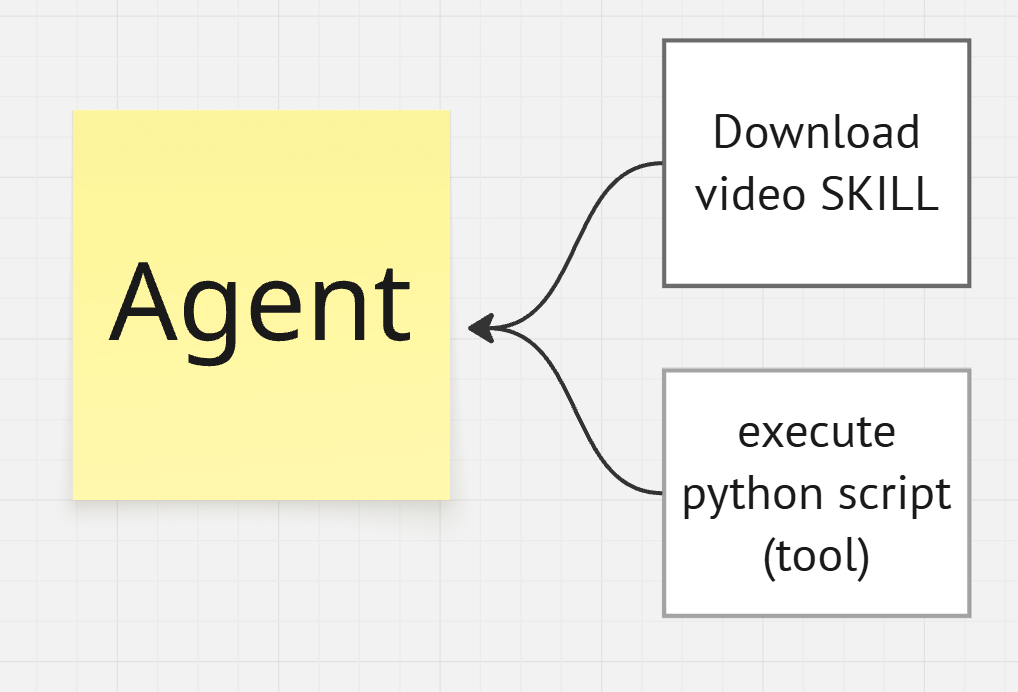

In [33]:
# ============================================================
# Reactive Agent с external skill (YouTube Video Downloader)
# ============================================================

# --- Инструменты агента ---

# 1. read_skill — загрузить процедуру skill
EXTERNAL_SKILLS_REGISTRY = {
    video_skill_adapted.name: video_skill_adapted,
}


def read_external_skill(name: str) -> str:
    """Загрузить skill по имени."""
    if name in EXTERNAL_SKILLS_REGISTRY:
        skill = EXTERNAL_SKILLS_REGISTRY[name]
        return f"═══ SKILL ЗАГРУЖЕН: {skill.title} ═══\n\nСТРОГО следуй этой процедуре шаг за шагом.\n\n{skill.content}"
    available = ", ".join(EXTERNAL_SKILLS_REGISTRY.keys())
    return f"Skill '{name}' не найден. Доступные: {available}"


# 2. execute_command — выполнить shell-команду (для запуска скриптов)
# def execute_command(command: str, timeout: int = 120) -> str:
#     """
#     Выполнить shell-команду и вернуть результат.

#     Ограничения безопасности:
#     - Команда выполняется в рабочей директории проекта
#     - Таймаут по умолчанию 120 секунд
#     """
#     try:
#         result = subprocess.run(
#             command,
#             shell=True,
#             capture_output=True,
#             text=True,
#             timeout=timeout,
#             cwd=str(PROJECT_ROOT),
#         )
#         output = ""
#         if result.stdout:
#             output += f"STDOUT:\n{result.stdout}\n"
#         if result.stderr:
#             output += f"STDERR:\n{result.stderr}\n"
#         output += f"Exit code: {result.returncode}"
#         return output or "Команда выполнена без вывода."
#     except subprocess.TimeoutExpired:
#         return f"Команда превысила таймаут ({timeout} сек)."
#     except Exception as e:
#         return f"Ошибка выполнения: {str(e)}"


def execute_command(command: str, timeout: int = 120) -> str:
    """
    Выполнить shell-команду и вернуть результат.

    Ограничения безопасности:
    - Команда выполняется в рабочей директории проекта
    - Таймаут по умолчанию 120 секунд
    """
    try:
        # Устанавливаем UTF-8 для корректной работы с кириллицей в путях
        env = os.environ.copy()
        env["PYTHONIOENCODING"] = "utf-8"
        result = subprocess.run(
            command,
            shell=True,
            capture_output=True,
            text=True,
            timeout=timeout,
            cwd=str(PROJECT_ROOT),
            encoding="utf-8",
            errors="replace",
            env=env,
        )
        output = ""
        if result.stdout:
            output += f"STDOUT:\n{result.stdout}\n"
        if result.stderr:
            output += f"STDERR:\n{result.stderr}\n"
        output += f"Exit code: {result.returncode}"
        return output or "Команда выполнена без вывода."
    except subprocess.TimeoutExpired:
        return f"Команда превысила таймаут ({timeout} сек)."
    except Exception as e:
        return f"Ошибка выполнения: {str(e)}"


# --- Описания инструментов в формате OpenAI ---

VIDEO_AGENT_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "read_skill",
            "description": (
                "Загрузить детальную процедуру (skill) для решения задачи. "
                "Вызывай, когда задача соответствует одному из доступных skills."
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "name": {
                        "type": "string",
                        "description": "Имя skill (например: youtube-downloader)",
                    }
                },
                "required": ["name"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "execute_command",
            "description": (
                "Выполнить shell-команду. Используй для запуска скриптов, "
                "установки пакетов и других системных операций."
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "command": {
                        "type": "string",
                        "description": "Shell-команда для выполнения",
                    },
                    "timeout": {
                        "type": "integer",
                        "description": "Таймаут в секундах (по умолчанию 120)",
                        "default": 120,
                    },
                },
                "required": ["command"],
            },
        },
    },
]


# --- System prompt с Level 1 метаданными ---

skills_meta_lines = ["ДОСТУПНЫЕ SKILLS:"]
for name, info in EXTERNAL_SKILLS_REGISTRY.items():
    skills_meta_lines.append(f"• {name}: {info.title}")
    skills_meta_lines.append(f"  {info.trigger_description[:150]}")
    skills_meta_lines.append("")

EXTERNAL_SKILLS_METADATA = "\n".join(skills_meta_lines)

VIDEO_AGENT_SYSTEM_PROMPT = f"""Ты полезный ассистент с возможностью выполнять команды и использовать skills.

Правила:
- Если задача соответствует доступному skill — СНАЧАЛА вызови read_skill(name), чтобы получить процедуру
- После загрузки skill — СТРОГО следуй его инструкциям шаг за шагом
- Для выполнения команд используй execute_command
- Сообщай пользователю о результатах на русском языке

═══════════════════════════════════════════
{EXTERNAL_SKILLS_METADATA}═══════════════════════════════════════════"""

print("System prompt:")
print(VIDEO_AGENT_SYSTEM_PROMPT)
print(f"\n📏 Размер: {count_tokens(VIDEO_AGENT_SYSTEM_PROMPT)} токенов")

System prompt:
Ты полезный ассистент с возможностью выполнять команды и использовать skills.

Правила:
- Если задача соответствует доступному skill — СНАЧАЛА вызови read_skill(name), чтобы получить процедуру
- После загрузки skill — СТРОГО следуй его инструкциям шаг за шагом
- Для выполнения команд используй execute_command
- Сообщай пользователю о результатах на русском языке

═══════════════════════════════════════════
ДОСТУПНЫЕ SKILLS:
• youtube-downloader: YouTube Video Downloader
  Download YouTube videos with customizable quality and format options. Use this skill when the user asks to download, save, or grab YouTube videos. Sup
═══════════════════════════════════════════

📏 Размер: 151 токенов


In [34]:
# ============================================================
# Reactive Agent с external skill — полный агентный цикл
# ============================================================


async def run_video_agent(
    question: str,
    max_steps: int = 10,
    verbose: bool = True,
) -> AgentTrace:
    """
    Reactive Agent с внешними skills и execute_command.

    Без MCP — используем только локальные инструменты:
    - read_skill: загрузка процедуры
    - execute_command: выполнение shell-команд
    """
    trace = AgentTrace(question=question)

    messages = [
        {"role": "system", "content": VIDEO_AGENT_SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]

    if verbose:
        print(f"[State] Вопрос: {question}")

    prev_context_size = 0

    # Маппинг имён инструментов на функции
    tool_handlers = {
        "read_skill": lambda args: read_external_skill(args.get("name", "")),
        "execute_command": lambda args: execute_command(
            args.get("command", ""),
            args.get("timeout", 120),
        ),
    }

    for step_num in range(1, max_steps + 1):
        current_step = AgentStep(step_number=step_num)

        if verbose:
            print(f"\n{'=' * 50}")
            print(f"--- Шаг {step_num} ---")
            print(f"  [Decision] LLM анализирует состояние...")

        # === DECISION ===
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=VIDEO_AGENT_TOOLS,
            tool_choice="auto",
            temperature=0,
        )

        u = _extract_usage(response)
        current_step.prompt_tokens = u["prompt_tokens"]
        current_step.cached_tokens = u["cached_tokens"]
        current_step.context_size = u["context_size"]
        current_step.context_size_delta = current_step.context_size - prev_context_size
        current_step.completion_tokens = u["completion_tokens"]
        current_step.total_tokens = u["total_tokens"]

        trace.prompt_tokens_total += current_step.prompt_tokens
        trace.completion_tokens_total += current_step.completion_tokens
        trace.total_tokens_total += current_step.total_tokens
        trace.latest_context_size = current_step.context_size
        trace.max_context_size = max(trace.max_context_size, current_step.context_size)
        prev_context_size = current_step.context_size

        if verbose:
            print(
                f"  [Tokens] context={current_step.context_size} "
                f"(Δ {current_step.context_size_delta:+}) "
                f"[cached={current_step.cached_tokens}, miss={current_step.prompt_tokens}], "
                f"completion={current_step.completion_tokens}"
            )

        msg = response.choices[0].message
        messages.append(msg)

        # === STOP ===
        if not msg.tool_calls:
            current_step.final_answer = msg.content
            trace.steps.append(current_step)
            trace.total_steps = step_num
            trace.final_answer = msg.content
            if verbose:
                print(f"  [Decision] → Финальный ответ (нет tool_calls)")
                print(f"  [Result] {msg.content}")
            return trace

        # === ACTION ===
        if verbose:
            print(f"  [Decision] → Вызвать {len(msg.tool_calls)} инструмент(ов)")

        for tool_call in msg.tool_calls:
            func_name = tool_call.function.name
            raw_args = tool_call.function.arguments
            args = json.loads(raw_args) if isinstance(raw_args, str) else raw_args

            current_step.tool_calls.append({"name": func_name, "args": args})

            handler = tool_handlers.get(func_name)
            if handler:
                result_text = handler(args)
            else:
                result_text = json.dumps({"error": f"Unknown tool: {func_name}"}, ensure_ascii=False)

            if verbose:
                if func_name == "read_skill":
                    print(f"  [Action] read_skill({args.get('name', '')})")
                    print(f"  [Observation] Level 2 загружен ({count_tokens(result_text)} токенов)")
                else:
                    print(f"  [Action] {func_name}({args})")
                    preview = result_text[:200]
                    print(f"  [Observation] {preview}{'...' if len(result_text) > 200 else ''}")

            try:
                result_parsed = json.loads(result_text)
            except (json.JSONDecodeError, TypeError):
                result_parsed = result_text

            current_step.observations.append(result_parsed)

            messages.append(
                {
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "content": result_text,
                }
            )

        if verbose:
            print(f"  [State_i] Состояние обновлено (messages: {len(messages)})")

        trace.steps.append(current_step)

    trace.total_steps = max_steps
    trace.final_answer = "[Агент не завершил работу за отведённое число шагов]"
    return trace

### Шаг 4. Запускаем агента

Попросим агента скачать видео. Агент должен:
1. Распознать задачу → вызвать `read_skill("youtube-downloader")`
2. Получить процедуру из SKILL.md
3. Сформировать команду и вызвать `execute_command`

> **Примечание**: для реального скачивания нужен установленный `yt-dlp`. Здесь мы наблюдаем за **поведением агента** — как он читает skill и следует процедуре. Если `yt-dlp` не установлен, агент попробует его установить (это тоже часть skill-инструкции).

In [36]:
# ============================================================
# Тест: агент с external skill (YouTube Video Downloader)
# ============================================================

print("╔" + "═" * 58 + "╗")
print("║   Тест: Reactive Agent + external skill (video-downloader)║")
print("╚" + "═" * 58 + "╝\n")

trace_video = asyncio.get_event_loop().run_until_complete(
    run_video_agent(
        r"""Скачай вот это видео с YouTube качество best: https://www.youtube.com/watch?v=dQw4w9WgXcQ
        Сохрани сюда C:\Users\isami\hse""",
        verbose=True,
    )
)

print("\n" + "=" * 55)
print("ТРАССИРОВКА")
print("=" * 55)
print(trace_video.summary())

╔══════════════════════════════════════════════════════════╗
║   Тест: Reactive Agent + external skill (video-downloader)║
╚══════════════════════════════════════════════════════════╝

[State] Вопрос: Скачай вот это видео с YouTube качество best: https://www.youtube.com/watch?v=dQw4w9WgXcQ
        Сохрани сюда C:\Users\isami\hse

--- Шаг 1 ---
  [Decision] LLM анализирует состояние...
  [Tokens] context=343 (Δ +343) [cached=0, miss=343], completion=16
  [Decision] → Вызвать 1 инструмент(ов)
  [Action] read_skill(youtube-downloader)
  [Observation] Level 2 загружен (1352 токенов)
  [State_i] Состояние обновлено (messages: 4)

--- Шаг 2 ---
  [Decision] LLM анализирует состояние...
  [Tokens] context=1719 (Δ +1376) [cached=0, miss=1719], completion=134
  [Decision] → Вызвать 1 инструмент(ов)
  [Action] execute_command({'command': '"c:/Users/isami/OneDrive/Рабочий стол/Projects/Personal/ВШЭ/HSE-Agent-Systems_2026/.venv/Scripts/python.exe" c:/Users/isami/OneDrive/Рабочий стол/Projects/Pers

---
## 7. Ограничения текущей реализации: stdio — только локально

### Что мы имеем сейчас

Во всей практике мы использовали **stdio-транспорт**: MCP-клиент запускает сервер как дочерний процесс (`subprocess`) и общается с ним через `stdin`/`stdout`.

```
┌────────────────────────────────────┐
│  Один процесс / одна машина        │
│                                    │
│  Agent (MCP Client)                │
│       │ stdin/stdout               │
│       ▼                            │
│  MCP Server (subprocess)           │
└────────────────────────────────────┘
```

```python
# Наш текущий код — stdio транспорт
server_params = StdioServerParameters(
    command=sys.executable,
    args=[SERVER_PATH],  # запускаем .py как subprocess
)
```

### В чём проблема?

| Ограничение | Почему это плохо |
|-------------|-----------------|
| **Один клиент — один сервер** | Каждый агент запускает свой экземпляр сервера. Нельзя расшарить сервер между агентами |
| **Только локально** | Клиент и сервер обязаны быть на одной машине — нет сетевого доступа |
| **Нет масштабирования** | 10 агентов = 10 процессов сервера, каждый со своими данными |
| **Нет аутентификации** | stdio не поддерживает авторизацию — кто угодно с доступом к процессу может вызывать инструменты |
| **Сложная отладка** | Логи смешиваются со stdout, нет HTTP-инструментов для мониторинга |

```
❌ Текущая ситуация (stdio):

Агент A ──► subprocess ──► MCP Server (копия 1)
Агент B ──► subprocess ──► MCP Server (копия 2)   ← дублирование!
Агент C ──► subprocess ──► MCP Server (копия 3)
```

---

### Что нужно для продакшена: HTTP/SSE и Streamable HTTP

MCP определяет **несколько транспортов**. Помимо `stdio`, есть сетевые:

#### 1. SSE (Server-Sent Events) — устаревающий, но рабочий

```
┌──────────┐   HTTP POST (запросы)    ┌──────────────┐
│  Agent A ├─────────────────────────►│              │
│          │◄─────────────────────────┤  MCP Server  │
│          │   SSE stream (ответы)    │  (HTTP)      │
└──────────┘                          │              │
┌──────────┐   HTTP POST              │              │
│  Agent B ├─────────────────────────►│              │
│          │◄─────────────────────────┤              │
└──────────┘   SSE stream             └──────────────┘
```

- Клиент отправляет JSON-RPC через `POST`
- Сервер стримит ответы через Server-Sent Events
- Один сервер обслуживает **много** клиентов одновременно

#### 2. Streamable HTTP — актуальный транспорт (спецификация 2025-03-26)

Это **рекомендованный** сетевой транспорт в текущей версии MCP. Основные отличия от SSE:

- Единый эндпоинт `/mcp` для всех запросов (вместо отдельных `/sse` и `/messages`)
- Сервер **может** отвечать обычным HTTP-ответом или открывать SSE-стрим — в зависимости от ситуации
- Поддержка **stateless-серверов** (не обязательно держать сессию)
- Возможность работать через обычные HTTP-прокси, балансировщики и CDN

```
┌──────────┐                          ┌──────────────┐
│  Agent A ├──── POST /mcp ──────────►│              │
│          │◄─── HTTP response ───────┤  MCP Server  │
└──────────┘     (или SSE stream)     │  (Streamable │
┌──────────┐                          │   HTTP)      │
│  Agent B ├──── POST /mcp ──────────►│              │
│          │◄─── SSE stream ──────────┤              │
└──────────┘                          └──────────────┘
```

---

### Как перевести наш сервер на HTTP

На стороне **сервера** — минимальные изменения:

```python
# Было (stdio — только локально):
if __name__ == "__main__":
    mcp.run(transport="stdio")

# Стало (Streamable HTTP — доступно по сети):
if __name__ == "__main__":
    mcp.run(transport="streamable-http", host="0.0.0.0", port=8080)
```

На стороне **клиента** — меняем тип подключения:

```python
# Было (stdio):
from mcp.client.stdio import stdio_client

server_params = StdioServerParameters(
    command=sys.executable,
    args=["space_mcp_server.py"],
)
async with stdio_client(server_params) as (read, write):
    ...

# Стало (Streamable HTTP):
from mcp.client.streamable_http import streamablehttp_client

async with streamablehttp_client("http://my-server:8080/mcp") as (read, write, _):
    async with ClientSession(read, write) as session:
        await session.initialize()
        # дальше всё то же самое — tools/list, tools/call, ...
```

> **Ключевой момент**: весь агентный код **не меняется** — меняется только способ подключения. Discovery, вызовы инструментов, формат сообщений — всё остаётся прежним.

---

### Развёртывание MCP-сервера в продакшене

Для реального использования MCP-сервер нужно развернуть как **сетевой сервис**:

| Подход | Описание | Когда использовать |
|--------|----------|-------------------|
| **Локальный HTTP** | `mcp.run(transport="streamable-http", port=8080)` | Разработка, тестирование нескольких агентов локально |
| **Docker-контейнер** | Упаковать сервер в Docker, запустить на сервере | Изоляция, воспроизводимость, CI/CD |
| **Облачный сервер (VPS)** | Развернуть на VPS (AWS EC2, Yandex Cloud и т.д.) | Доступ из любой точки, для команды |
| **Serverless** | AWS Lambda, Cloud Functions + API Gateway | Автомасштабирование, оплата за вызовы |
| **Kubernetes** | Несколько реплик за load balancer | Высокая нагрузка, отказоустойчивость |

#### Что добавить при развёртывании

```
┌────────────┐     HTTPS      ┌───────────┐      ┌──────────────┐
│  Agent A   ├───────────────►│  Reverse  │─────►│  MCP Server  │
│  Agent B   ├───────────────►│  Proxy    │      │  (контейнер) │
│  Agent C   ├───────────────►│  (nginx)  │      └──────────────┘
└────────────┘                └─────┬─────┘
                                    │
                              ┌─────┴─────┐
                              │ - TLS/SSL │
                              │ - Auth    │
                              │ - Rate    │
                              │   limits  │
                              └───────────┘
```

| Компонент | Зачем нужен |
|-----------|-------------|
| **HTTPS (TLS)** | Шифрование трафика — данные инструментов не летят открытым текстом |
| **Аутентификация** | API-ключи, OAuth2, JWT — только авторизованные агенты могут подключаться |
| **Rate limiting** | Защита от перегрузки — ограничить число вызовов на агента |
| **Логирование** | Кто, когда, какой инструмент вызвал — аудит и отладка |
| **Health checks** | `/health` эндпоинт для мониторинга доступности сервера |

---

### Итог: stdio vs HTTP

| | stdio (наша практика) | Streamable HTTP (продакшен) |
|---|---|---|
| **Область** | Один процесс, одна машина | Любая сеть |
| **Клиенты** | 1 клиент на 1 сервер | Много клиентов на 1 сервер |
| **Развёртывание** | Не нужно | Docker, облако, Kubernetes |
| **Аутентификация** | Нет | API keys, OAuth2, JWT |
| **Масштабирование** | Нет | Горизонтальное (реплики) |
| **Отладка** | Сложно (stdout) | HTTP-инструменты, логи |
| **Когда использовать** | Локальная разработка, IDE-плагины | Командная работа, продакшен |

> **stdio** отлично подходит для локальных сценариев (IDE, десктопные приложения).  
> **Streamable HTTP** — для всего остального: когда сервер и агенты живут на разных машинах или нужен общий доступ к инструментам.